# Neuromorficzny sensor wizyjny: Kamera zdarzeniowa

Zacznijmy od instalacji wszystkich potrzebnych bibliotek — zajmie to kilka minut.

W międzyczasie przeczytaj wprowadzenie i zacznij implementować pierwsze zadanie poniżej!

Przed rozpoczęciem utwórz proszę wirtualne środowisko Pythona.

In [19]:
import os
import glob
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import cv2
import snntorch as snn
from snntorch import surrogate
from snntorch import functional as SF
from snntorch import spikeplot as splt
from snntorch import utils
import matplotlib.pyplot as plt
from tqdm import tqdm
from torch.utils.data import DataLoader
from torch.nn import    Linear, \
                        BatchNorm1d, \
                        Module

from myutils import     GraphGen, \
                        PointNetConv, \
                        GraphPoolOut2D, \
                        read_dataset, \
                        collate_fn, \
                        GCN, \
                        forward_pass_snn, \
                        events_to_spike_tensor           
import graphgen

device = torch.device('cpu')
print('Available device:', device)

Available device: cpu


## 1. Czym jest kamera zdarzeniowa?

Kamera zdarzeniowa (ang. *event camera*), znana również jako Dynamic Vision Sensor (DVS), jest neuromorficznym sensorem inspirowanym ludzkim okiem.

W przeciwieństwie do klasycznych kamer, które rejestrują poziom jasności (koloru) dla danego piksela w określonych odstępach czasu (parametr liczby klatek na sekundę), DVS rejestruje zmiany jasności niezależnie (asynchronicznie) dla poszczególnych pikseli. W rezultacie dane przechwytywane przez kamerę nie zależą od zegara, lecz od dynamiki sceny. Na wyjściu otrzymujemy więc strumień zdarzeń, z których każde opisane jest przez 4 wartości:

$e = {t, x, y, p}$

gdzie: `t` oznacza czas zarejestrowania zdarzenia (*timestamp*), `x` oraz `y` są współrzędnymi piksela, natomiast `p` przyjmuje wartość 0 lub 1 odpowiadającą polaryzacji zdarzenia (dodatnia lub ujemna zmiana wartości piksela przekraczająca ustalony próg).

<p align="center">
  <img src="https://cdn.prod.website-files.com/64bea1df65b74226fa13e905/64eca0c842bb000fd2eeb4a9_event-cameras-computer-vision-motius-3.webp" width="500" alt="Centered Image">
</p>

Takie podejście niesie ze sobą wiele interesujących konsekwencji. Po pierwsze, pojedynczy piksel składa się z części analogowej oraz cyfrowej. Zmiany wykrywane są w części analogowej, co skutkuje **niskim opóźnieniem** (*low latency*, szybki czas reakcji) oraz **efektywnością energetyczną** (niewystarczająca zmiana oznacza, że część cyfrowa nie zostanie aktywowana). Dodatkowo analiza logarytmu zmiany jasności każdego piksela niezależnie pozwala uzyskać **wysoki zakres dynamiki** (*high dynamic range*, powyżej 120 dB). Dzięki temu sensory DVS są stosunkowo odporne na duże różnice jasności w rejestrowanej scenie, które stanowią problem dla klasycznych kamer (część obrazu jest prześwietlona lub zbyt ciemna). Właściwość ta umożliwia również poprawne wykrywanie obiektów nawet przy bardzo silnym lub ograniczonym oświetleniu.

Po drugie, przesyłanie informacji wyłącznie o zachodzących zmianach eliminuje zazwyczaj niepożądaną redundancję (tradycyjna kamera przesyła informacje o stanie wszystkich pikseli, nawet tych, których jasność się nie zmieniła). Kolejną cechą kamer zdarzeniowych jest ich bardzo wysoka częstotliwość próbkowania — znacznik czasu posiada rozdzielczość mikrosekund. Dodatkowo strumień danych z kamery może osiągać nawet 1200 MEPS (*million events per second* — milionów zdarzeń na sekundę) w zależności od zastosowanego układu oraz interfejsu sprzętowego. **Ograniczenie redundantnych informacji** oraz **wysoka częstotliwość próbkowania** umożliwiają przetwarzanie kluczowych danych nawet w warunkach dużej zmienności, czyli wtedy, gdy obiekty rejestrowane przez kamerę poruszają się względem niej z bardzo dużą prędkością.

### Podczas dzisiejszych zajęć przyjrzymy się bliżej danym zdarzeniowym i nauczymy się, jak je przetwarzać w przykładowym zadaniu z zakresu widzenia komputerowego: klasyfikacji obiektów!

Na potrzeby dzisiejszego ćwiczenia użyjemy zbioru danych **N-MNIST** — prostego przykładu danych zdarzeniowych o rozdzielczości zaledwie 34×34 piksele. Zbiór danych zawiera oznaczone sekwencje przedstawiające odręczne cyfry od 0 do 9.

Więcej informacji znajdziesz tutaj: https://www.garrickorchard.com/datasets/n-mnist

Wraz z tym notebookiem znajdziesz losowo wybrany przykład z tego zbioru danych.

In [20]:
# If you want, you can try this exercise with any other sample from N-MNIST dataset, it is avaliable online
# Just update the following PATH to any other binery file from the dataset.
PATH = "example_sample.bin" 

timestamps, xaddr, yaddr, polarities, height, width = read_dataset(PATH) # return 4 lists and 2 integers

Oto nasze **przykładowe zdarzenia (events)**!

Przeanalizuj te listy:
- znacznik czasu (*timestamp*) jest zakodowany w mikrosekundach — jak długi jest ten ciąg?
- ile zdarzeń znajduje się w tej sekwencji?
- w jaki sposób zakodowana jest polaryzacja?
- jaka jest rozdzielczość używanej kamery?

In [21]:
print(f"Długość ciągu: {(timestamps[-1]-timestamps[0])/1000:.2f} ms")
print(f"Ilość zdarzeń w sekwencji: {len(timestamps)}")
print(f"Wartości polaryzacji: {[int(v) for v in set(polarities)]}")
print(f"Rozdzielczość kamery: {width}x{height}")

Długość ciągu: 304.47 ms
Ilość zdarzeń w sekwencji: 5098
Wartości polaryzacji: [0, 1]
Rozdzielczość kamery: 34x34


Zanim zaczniemy analizować ten przykład, ograniczmy liczbę zdarzeń, aby umożliwić bardziej efektywne przetwarzanie i wizualizację.

Przefiltrujemy tylko te zdarzenia, których znaczniki czasu mieszczą się w zakresie od 100 ms do 200 ms, tworząc w ten sposób sekwencję o długości 100 ms.

W tym celu przejdź przez wszystkie zdarzenia i zapisz tylko te, które spełniają ten warunek, do nowych list:

In [22]:
sample_ts = []
sample_xs = []
sample_ys = []
sample_ps = []
for i in range (len(timestamps)):
    if 100_000 <= timestamps[i] <= 200_000:
        sample_ts.append(timestamps[i])
        sample_xs.append(xaddr[i])
        sample_ys.append(yaddr[i])
        sample_ps.append(polarities[i])

How many events do we have left?

In [23]:
print(f"Ilość zdarzeń: {len(sample_ts)}")

Ilość zdarzeń: 1774


Teraz zwizualizujemy zdarzenia!

Każde zdarzenie ma cztery wartości: t, x, y oraz p.

Stworzymy wykres 3D, aby zwizualizować zdarzenia w przestrzeni x, y oraz czasu. W tym celu użyjemy biblioteki `matplotlib` oraz funkcji `scatter3D`.

Dodatkowo użyjemy kolorów — niebieskiego i czerwonego — aby odróżnić zdarzenia negatywne i pozytywne.

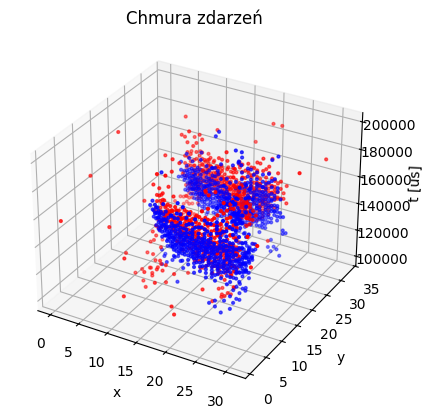

In [24]:
# Use plt for visualisation
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
colors = ["red" if bool(p) else "blue" for p in sample_ps]
ax.scatter3D(sample_xs, sample_ys, sample_ts, c=colors, s=4)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("t [us]")
ax.set_title("Chmura zdarzeń")
plt.show()

To jest nasza rzadka chmura punktów w przestrzeni-czasie!

Jednak trudno analizować dane przy użyciu takiej wizualizacji.

Spróbuj zmienić kąt widzenia wykresu za pomocą `ax.view_init(elev=?, azim=?)`. Spróbuj zobaczyć tylko wymiary x i y, x i t oraz y i t.

Następnie spróbuj odpowiedzieć na następujące pytania:
- która cyfra została zapisana w tej sekwencji?
- kamera zdarzeniowa rejestruje tylko dynamikę sceny (np. ruch). Jaki jest kierunek ruchu w tej scenie?

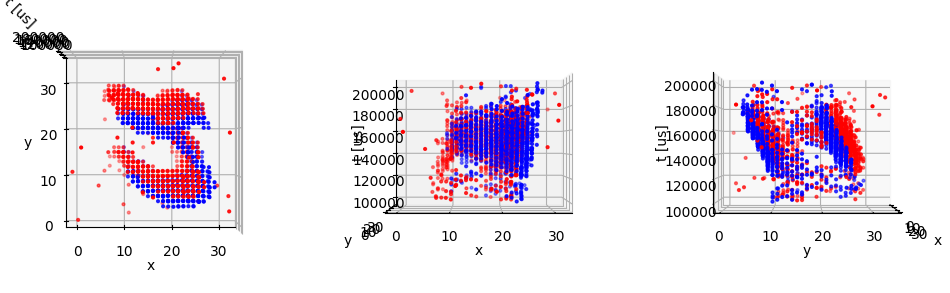

In [25]:
fig, axs = plt.subplots(1, 3, subplot_kw={"projection": "3d"}, figsize=(12, 12))
for ax, (elev, azim) in zip(axs, ((90, -90), (0, -90), (0, 0))):
    colors = ["red" if bool(p) else "blue" for p in sample_ps]
    ax.scatter3D(sample_xs, sample_ys, sample_ts, c=colors, s=4)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("t [us]")
    ax.view_init(elev=elev, azim=azim)
plt.show()

## 2. Przetwarzanie danych zdarzeniowych – reprezentacje event-frame

Spróbujmy odpowiedzieć na pytanie: **Jak możemy w pełni wykorzystać zalety kamery DVS w widzeniu komputerowym?**

Ponieważ dane generowane przez kamerę zdarzeniową mają postać rzadkiej chmury punktów w czasoprzestrzeni, ich przetwarzanie przy użyciu klasycznych algorytmów widzenia komputerowego (które są projektowane dla danych obrazowych — macierzy wartości pikseli) jest trudne.

Zacznijmy od najprostszego podejścia. Ponieważ mamy już tysiące algorytmów widzenia komputerowego opracowanych na przestrzeni ponad 70 lat, spróbujmy stworzyć **obrazową reprezentację danych zdarzeniowych**! Podejście jest proste:

- Agregujemy zdarzenia w określonym oknie czasowym (w naszym przypadku 100 ms).
- Tworzymy pustą klatkę (macierz) o rozmiarze odpowiadającym rozdzielczości kamery zdarzeniowej.
- Reprezentujemy zdarzenia jako wartości pikseli w tej klatce.

W tym ćwiczeniu zaimplementujemy najprostszą reprezentację danych zdarzeniowych: **event frame**.

Idea jest następująca:

- Inicjalizujemy ramkę kolorem szarym (wartość piksela 127).
- Dla każdego zdarzenia w sekwencji:
  - Aktualizujemy odpowiedni piksel (o współrzędnych `x` i `y`) na **biały** (wartość 0) dla polaryzacji ujemnej.
  - Aktualizujemy go na **czarny** (wartość 255) dla polaryzacji dodatniej.

Zaimplementuj funkcję `event_frame` i użyj jej dla naszej sekwencji!

In [26]:
def event_frame(x_coords, y_coords, polarities, image_shape):
    image = np.full(image_shape, 127, dtype=np.uint8)

    for x, y, p in zip(x_coords, y_coords, polarities):
        if p == 1:
            image[y, x] = 255
        else:
            image[y, x] = 0

    return image

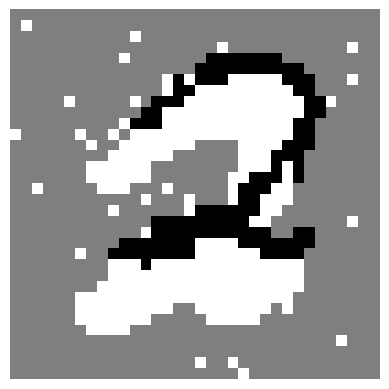

In [27]:
image = event_frame(sample_xs, sample_ys, sample_ps, (height, width))
plt.imshow(image, cmap="gray")
plt.axis('off')
plt.show()

Teraz powinno być już jasne, jaka liczba znajduje się w tej sekwencji!

Odpowiedz na pytania: Jakie informacje zostały utracone ze względu na tę formę reprezentacji danych? Jakie zostały zachowane?

In [28]:
# Utracone informacje:
# - dokładny czas każdego zdarzenia
# - kolejność zdarzeń
# - liczba zdarzeń w tym samym pikselu

# Zachowane informacje:
# - położenie zdarzeń w przestrzeni
# - polaryzacja ostatniego zdarzenia w danym pikselu
# - ogólny kształt cyfry

Przetwórzmy ten obraz przy użyciu sieci neuronowej do klasyfikacji!

W zadaniach z widzenia komputerowego standardowo wykorzystuje się **konwolucyjne sieci neuronowe (CNN)**. Wytrenowaliśmy jedną dla Ciebie — możesz znaleźć plik `cnn.keras` na dysku z zapisanym modelem.

Załaduj model i użyj go do predykcji. Wyjście sieci to `num_classes` wartości, z których każda reprezentuje prawdopodobieństwo, że obraz odpowiada jednej z cyfr.

- Jaka jest predykcja modelu?  Czy jest poprawna?
- Jak bardzo sieć jest pewna swojej predykcji?

In [29]:
#Accuracy is 98.14%
model = tf.keras.models.load_model("cnn.keras")
model.summary()

sample = image.reshape(1, height, width, 1)

num_classes = 10

predict = model.predict(sample, batch_size=1)

predicted_class = np.argmax(predict)
confidence = np.max(predict)

print("Predykcja:", predicted_class)
print("Pewność:", confidence)
print("Wynik sieci:", [f"{p:.2f}" for p in predict[0]])

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 34, 34, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 5, 5, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 269,984 (1.03 MB)

 Trainable params: 89,994 (351.54 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 179,990 (703.09 KB)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Predykcja: 2
Pewność: 0.9999999
Wynik sieci: ['0.00', '0.00', '1.00', '0.00', '0.00', '0.00', '0.00', '0.00', '0.00', '0.00']


### Uwaga dodatkowa

To nie jest jedyny sposób reprezentowania danych zdarzeniowych w formie „obrazowej”. Reprezentowanie nieznanej liczby zdarzeń (zależnej od dynamiki sceny) za pomocą stałej i ograniczonej liczby wartości pikseli zawsze wiąże się z pewną **utratą informacji**. Istnieje jednak wiele różnych podejść, które pozwalają maksymalnie wykorzystać tę reprezentację.

Zainteresowany? Przeczytaj artykuł [Traffic Sign Detection With Event Cameras and DCNN](https://arxiv.org/abs/2207.13345), w którym badamy i porównujemy kilka innych typów reprezentacji typu event-frame.

## 3. Przetwarzanie danych zdarzeniowych – reprezentacje event-graph

Istnieją dwa główne problemy związane z reprezentacjami typu event-frame. Pierwszy z nich został już omówiony — **utrata informacji**. Drugi jest prostszy: podczas przetwarzania gęstych macierzy obrazowych tracimy jedną z największych zalet kamer zdarzeniowych — **rzadkość danych (sparsity)** oraz redukcję informacji redundantnej. W efekcie przetwarzamy każdy piksel, nawet jeśli nie wygenerował żadnego zdarzenia!

Spróbujmy więc innego podejścia. Wykorzystamy tzw. **event-grafy**, w których każde zdarzenie jest reprezentowane jako wierzchołek, a krawędzie łączą je w określonym sąsiedztwie, aby umożliwić analizę lokalnych relacji między zdarzeniami.

### Eventy jako chmura punktów

Lepsze spojrzenie: każde zdarzenie $e_i = (x_i, y_i, t_i, p_i)$ jest **punktem w przestrzeni 3D** $(x, y, t)$ z cechą skalarną $p \in \{-1, +1\}$.  
Cały strumień eventów można traktować jako **chmurę punktów** — dokładnie taki typ danych, dla którego pierwotnie zaprojektowano metody grafowe.

Taka struktura może zostać wzbogacona przez wprowadzenie **krawędzi łączących punkty w lokalnych sąsiedztwach**, tworząc reprezentację grafową. W tym ujęciu pojedyncze eventy są **węzłami (vertexami)**, a krawędzie opisują **lokalne relacje między nimi**.

Relacje te mogą być definiowane na różne sposoby, np. na podstawie bliskości w przestrzeni obrazu, sąsiedztwa czasowego lub bardziej zaawansowanych metryk podobieństwa. W efekcie strumień eventów nie jest już traktowany jako nieustrukturyzowany zbiór niezależnych próbek, ale jako graf, który jawnie koduje geometrię i dynamikę danych.

---

### Od konwolucji do konwolucji grafowej — analogia

W klasycznej 2D CNN konwolucja agreguje informacje z **sąsiedztwa przestrzennego** piksela.  
**Graph convolution** robi to samo, ale sąsiedztwo definiowane jest przez **krawędzie grafu**, a nie stałą siatkę:

<p align="center">
  <img src="GCNN.png" width="500" alt="GCNN">
</p>

| Dense CNN | Graph Conv |
|----------|-------------|
| Wejście: mapa cech H × W | Wejście: macierz cech węzłów N × F |
| Sąsiedztwo: stałe okno k×k | Sąsiedztwo: krawędzie grafu |
| Agregacja: ważona suma w oknie | Agregacja: uczona funkcja na połączonych węzłach |
| Współdzielone wagi na całej mapie | Współdzielone wagi na wszystkich węzłach |

Kluczowa idea: gdy mamy graf nad chmurą punktów eventów, konwolucja grafowa jest konceptualnie *tym samym działaniem* co konwolucja przestrzenna — tylko wykonywanym na nieregularnej, rzadkiej strukturze.

---

### Dlaczego łączymy eventy w osi *czasu*?

W tym laboratorium używamy schematu **spatio-temporal radius**: event $i$ jest łączony z eventem $j$, jeśli znajdują się w promieniu $r$ w przestrzeni $(x, y, t)$.  
Ponieważ eventy przetwarzane są w kolejności czasowej, krawędzie prowadzą wyłącznie od wcześniejszych do późniejszych zdarzeń — graf ma więc postać **grafu skierowanego (DAG)**.

Ma to bardzo praktyczną zaletę: graf może być aktualizowany **inkrementalnie** wraz z napływem nowych eventów.  
Nowy węzeł jest dodawany, jego połączenia z wcześniejszymi eventami są tworzone, a konwolucja wykonywana jest lokalnie — bez ponownego przetwarzania całego okna.  
To umożliwia prawdziwie niskolatencyjne, asynchroniczne przetwarzanie na brzegu systemu (edge inference).

#### Reguła budowy grafu

Event $j$ (docelowy) otrzymuje krawędź **od** eventu $i$ (źródłowego), jeśli:

$$
\sqrt{(x_i - x_j)^2 + (y_i - y_j)^2 + (t_i - t_j)^2} \leq r
$$

Każde otrzymane zdarzenie jest przypisywane do odpowiedniej komórki pikselowej w `neighbour_matrix`.  
Dla każdego piksela $(x, y)$ przechowywany jest tylko **najbardziej aktualny event**, więc każda komórka może mieć maksymalnie jeden aktywny węzeł w danym momencie. Pętle własne (`src == dst`) są dodawane domyślnie.

Poniżej znajduje się lista 7 przykładowych zdarzeń. Zgodnie z opisaną metodą budowy grafu, **zaimplementuj funkcję generującą listę krawędzi w grafie**:

- Dwa węzły powinny być połączone, jeśli ich odległość jest mniejsza lub równa \( R = 2 \)  
- Uwzględnij **pętle własne** (czyli każdy węzeł jest połączony sam ze sobą)

2. Ile krawędzi znajduje się w powstałym grafie?

3. Ile krawędzi jest przypisanych do każdego eventu (węzła)?

In [30]:
# Hand-crafted event stream:  (x, y, t, polarity)
# Must be ordered by time — GraphGen processes events sequentially.
raw_events = torch.tensor([
    [2, 3, 0.0,  1.0],
    [0, 0, 0.0, -1.0],
    [3, 3, 1.0,  1.0],
    [2, 1, 1.0,  1.0],
    [2, 2, 2.0,  1.0],
    [0, 2, 3.0, -1.0],
    [1, 2, 4.0,  1.0],
], dtype=torch.float32)

In [31]:
# ── parameters ───────────────────────────────────────────────────────────────
r = 2          # spatio-temporal radius (same value used by GraphGen above)

# Convert the raw event tensor to a plain Python list for easy looping
# Each element:  [x, y, t, polarity]
events = raw_events.tolist()

# ── Manual Graph Construction ────────────────────────────────────────────────
edges = []
last_events = {}

for i, (x, y, t, p) in enumerate(events):
    edges.append((i, i))

    for (x_prev, y_prev), j in last_events.items():
        t_prev = events[j][2]
        distance = np.sqrt((x - x_prev) ** 2 + (y - y_prev) ** 2 + (t - t_prev) ** 2)
        if distance <= r:
            edges.append((i, j))

    last_events[(x, y)] = i

# ── Analyze Graph ────────────────────────────────────────────────────────────
print("Edges:", edges)
print("Liczba krawędzi:", len(edges))

for i in range(len(events)):
    node_edges = [edge for edge in edges if edge[0] == i]
    print(f"Event {i}: {len(node_edges)} krawędzi -> {node_edges}")

Edges: [(0, 0), (1, 1), (2, 2), (2, 0), (3, 3), (4, 4), (4, 2), (4, 3), (5, 5), (6, 6), (6, 5)]
Liczba krawędzi: 11
Event 0: 1 krawędzi -> [(0, 0)]
Event 1: 1 krawędzi -> [(1, 1)]
Event 2: 2 krawędzi -> [(2, 2), (2, 0)]
Event 3: 1 krawędzi -> [(3, 3)]
Event 4: 3 krawędzi -> [(4, 4), (4, 2), (4, 3)]
Event 5: 1 krawędzi -> [(5, 5)]
Event 6: 2 krawędzi -> [(6, 6), (6, 5)]


Teraz wykorzystajmy nasz przykładowy plik ze zdarzeniami, aby wygenerować taki graf dla rzeczywistych danych. Uzupełnij brakujące fragmenty kodu.
Tym razem wykorzystamy udostepnioną funkcję `GraphGen()`

Możesz oglądać tę wizualizację pod różnymi kątami (podobnie jak w pierwszym ćwiczeniu z wykresami 3D).

In [33]:
# normalise 
# For graph neural networks we use NORMALIZED TIME - with values 0-31 
# We lose some temporal information, but for our toy example (N-MNIST) 5 bit timestamp precision is enough.
# Normalise timestamps to 0-31
# Use np.floor() for rounding.
ts = np.floor((np.array(sample_ts) - np.min(sample_ts)) / (np.max(sample_ts) - np.min(sample_ts)) * 31)

# For our GCN implementaton, we use events as one vector
events = np.column_stack((sample_xs, sample_ys, ts, sample_ps))
print(events)

[[23. 10.  0.  0.]
 [20. 16.  0.  1.]
 [22. 15.  0.  1.]
 ...
 [21. 18. 30.  0.]
 [16.  6. 30.  1.]
 [27.  8. 31.  0.]]


Features: torch.Size([1646, 1])
Positions: torch.Size([1646, 3])
Edges: torch.Size([20935, 2])
tensor([[   0,    0],
        [   1,    1],
        [   2,    2],
        ...,
        [1645, 1631],
        [1645, 1637],
        [1645, 1628]], dtype=torch.int32)


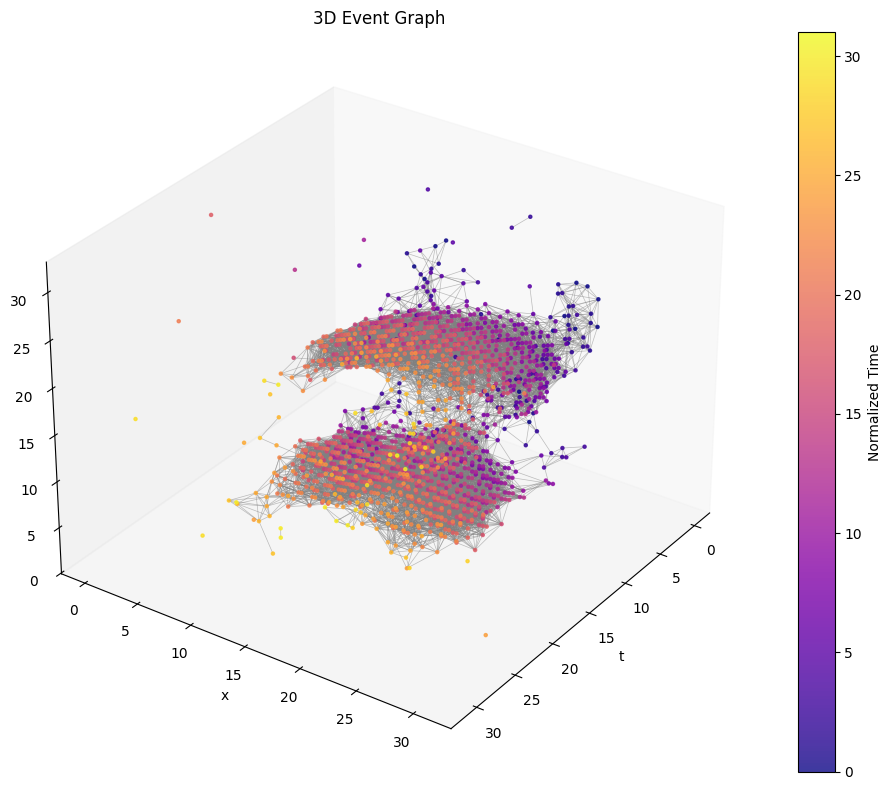

In [34]:
# Example use of graph generator
# For more in-depth exmplenation read the paper linked in "side note" below
# R is a radius for edge search in the graph
graph_gen = GraphGen(r=3, dimension_XY=32)
features, pos, edges = graph_gen.forward(events)

# How do you think: What are those values?
# What is an feature passed for first graph convolution...?
print("Features:", features.shape)
print("Positions:", pos.shape)
print("Edges:", edges.shape)
print(edges)

# Example use of graph visualisation
def draw_graph(pos, edges):
    pos_np = pos.numpy()
    edges_np = edges.numpy()
    
    # Extract coordinates
    x, y, t = pos_np[:, 0], pos_np[:, 1], pos_np[:, 2]
    
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    sc = ax.scatter(t, x, 32-y, c=t, cmap='plasma', s=5, alpha=0.8) # 32-y to flip Y-axis
    
    # Draw edges
    for (src, dst) in edges_np:
        if src < len(pos_np) and dst < len(pos_np):
            x_line = [pos_np[src, 0], pos_np[dst, 0]]
            y_line = [32-pos_np[src, 1], 32-pos_np[dst, 1]] # 32-y to flip Y-axis
            t_line = [pos_np[src, 2], pos_np[dst, 2]]
            ax.plot(t_line, x_line, y_line, color='gray', alpha=0.5, linewidth=0.5)
    
    ax.set_xlabel("t")
    ax.set_ylabel("x")
    ax.set_zlabel("y")
    ax.set_title("3D Event Graph")
    fig.colorbar(sc, ax=ax, label='Normalized Time')
    
    ax.view_init(elev=30, azim=35)
    ax.grid(False)
    
    plt.tight_layout()
    plt.show()

draw_graph(pos, edges)

Do wydajnego przetwarzania event-graphów używamy **Graph Convolutional Neural Networks (GCNN)**, gdzie konwolucja wykonywana jest na wierzchołkach połączonych krawędziami zamiast na sąsiednich pikselach. Wytrenowaliśmy jedną dla Ciebie — możesz znaleźć plik `gcn.pth` na dysku z zapisanym modelem.

Załaduj model i użyj go do predykcji. Wyjście sieci to 10 wartości, z których każda reprezentuje prawdopodobieństwo (pewność), że wejście odpowiada jednej z cyfr.

Uwaga: tym razem wartości **nie są znormalizowane do zakresu 0–1**. Zamiast tego im wyższa wartość, tym większa pewność sieci dla danej klasy.

- Jaka jest predykcja modelu?  Czy jest poprawna?
- Jak bardzo jest pewna swojej predykcji?

In [35]:
# Study the model summary
model = GCN()

# Load the model
checkpoint = torch.load(f"gcn.pth", map_location=torch.device('cpu'))
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

GCN(
  (conv1): PointNetConv(linear=Linear(in_features=4, out_features=32, bias=True))
  (norm1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): PointNetConv(linear=Linear(in_features=35, out_features=32, bias=True))
  (norm2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): PointNetConv(linear=Linear(in_features=35, out_features=32, bias=True))
  (norm3): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool_out): GraphPoolOut2D(pool_size=8, max_dimension=32)
  (linear): Linear(in_features=512, out_features=10, bias=True)
)

In [36]:
batch = torch.zeros(features.shape[0])
batch = torch.full((features.shape[0],), 0, dtype=torch.long)
out = model(features, pos, edges, batch)

# Study the output
print(out)

tensor([[-13.6892, -14.6712,  19.6682,  -5.5785, -14.6729, -18.1106,  -9.5135,
          -9.2146,  -5.0482, -12.0611]], grad_fn=<AddmmBackward0>)


### Uwaga dodatkowa

Zastosowanie **Graph Convolutional Neural Networks (GCNN)** do wydajnego przetwarzania danych zdarzeniowych jest obecnie jednym z najszybciej rozwijających się obszarów badań, szczególnie w kontekście urządzeń wbudowanych (edge devices). Ich implementacja na wyspecjalizowanym sprzęcie (FPGA) zapewnia wysoką dokładność, niską latencję oraz niskie zużycie energii, co jest kluczowe w robotyce mobilnej i systemach autonomicznych.

Zainteresowany? Przeczytaj artykuł [Embedded Graph Convolutional Networks for Real-Time Event Data Processing on SoC FPGAs](https://arxiv.org/html/2406.07318v1), w którym implementujemy GCNN do przetwarzania danych zdarzeniowych na układach FPGA.

## 4. Przetwarzanie danych zdarzeniowych – Spiking Neural Networks

Ponieważ kamery zdarzeniowe są inspirowane biologią ludzkiego oka, nazywamy je **sensorami neuromorficznymi**. Naturalne jest więc, że do przetwarzania ich danych używamy również **neuromorficznych narzędzi**.

**Spiking Neural Networks (SNN)** to rodzaj sztucznych sieci neuronowych zaprojektowanych tak, aby symulować zachowanie neuronów w mózgu. W tradycyjnych sieciach neuronowych (ANN) neurony mają ciągłe wartości aktywacji zmieniające się w czasie, natomiast w SNN neurony generują dyskretne „impulsy” (*spikes*) w określonych momentach.

SNN są inspirowane tym, jak działają neurony w mózgu. W mózgu neurony komunikują się za pomocą impulsów elektrycznych (spikes) przesyłanych wzdłuż aksonów. Te impulsy docierają do dendrytów innych neuronów i jeśli suma sygnałów przekroczy próg, neuron generuje własny impuls. SNN działają analogicznie:
- neuron ma określony poziom potencjału,
- potencjał zmienia się w czasie w zależności od wejść,
- jeśli przekroczy próg, neuron „wystrzeliwuje” spike do neuronów dalej,
- po wystrzale jego potencjał spada i następuje okres refrakcji.

<p align="center">
  <img src="https://mindkosh.com/media/images/spikingneural.original.jpg" width="500" alt="SNN">
</p>

SNN przyjmuje na wejściu zestaw spike’ów i generuje spike’i na wyjściu (ciągi spike’ów nazywamy *spike trains*). Ogólna idea:
- każdy neuron ma wartość odpowiadającą potencjałowi elektrycznemu,
- wartość zmienia się zgodnie z modelem matematycznym (np. rośnie lub maleje po otrzymaniu spike’a),
- po przekroczeniu progu neuron wysyła impuls do neuronów kolejnej warstwy,
- jego wartość spada i przechodzi w stan refrakcji,
- z czasem wraca do wartości bazowej.

---

Połączenie **kamery zdarzeniowej** z SNN jest bardzo naturalne — podajemy eventy bezpośrednio na wejście w momencie ich wystąpienia. Nie potrzebujemy żadnej pośredniej reprezentacji — możemy stworzyć end-to-end **neuromorficzny pipeline**. Wytrenowaliśmy dla Ciebie sieć SNN — plik `snn.pth` znajdziesz na dysku.

Załaduj model i użyj go do predykcji. Sieć ma 10 wyjść. Każde z nich może generować spiki w czasie. Aby zrozumieć predykcję, liczymy spiki na wyjściu modelu — im więcej spike’ów, tym większe prawdopodobieństwo danej klasy.

- Jaka jest predykcja modelu?  
- Czy sieć jest poprawna?  
- Jak bardzo jest pewna swojej predykcji?

In [37]:
# Define and load the SN model
beta = 0.5
spike_grad = surrogate.atan()
SNN = nn.Sequential(nn.Conv2d(2, 12, 5),
                    snn.Leaky(beta=beta, spike_grad=spike_grad, init_hidden=True),
                    nn.MaxPool2d(2),
                    nn.Conv2d(12, 32, 5),
                    snn.Leaky(beta=beta, spike_grad=spike_grad, init_hidden=True),
                    nn.MaxPool2d(2),
                    nn.Flatten(),
                    nn.Linear(32*5*5, 10),
                    snn.Leaky(beta=beta, spike_grad=spike_grad, init_hidden=True, output=True)
                    )
SNN.load_state_dict(torch.load("snn.pth", map_location=torch.device('cpu')))

<All keys matched successfully>

100%|██████████| 305/305 [00:00<00:00, 3674.71it/s]

Total spikes per channel: tensor([[ 77.,  69., 170., 158.,  69.,  67.,  67., 100.,  67.,  63.]],
       grad_fn=<SumBackward1>)
Predykcja: 2
Pewność: 170.0


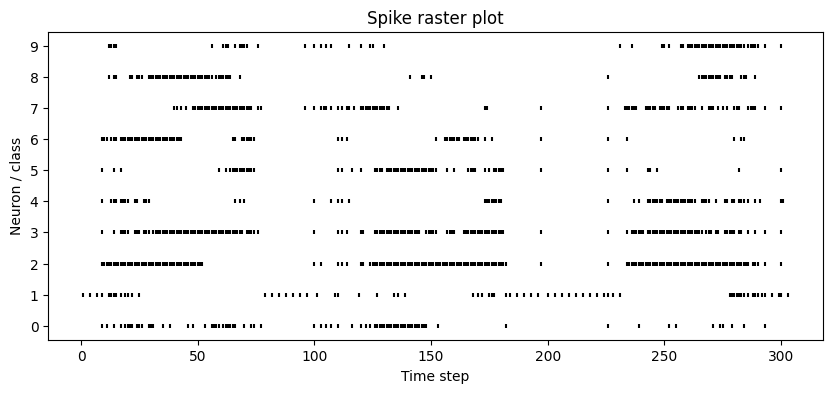

In [39]:
# For our SNN model, we need entire event stream, not just our 100 ms long sequence!
# Use correct lists!
events2 = np.column_stack((xaddr, yaddr, timestamps, polarities)) # x,y,t,p

# Convert event's to spikes (for compatibility with snntorch tool
spike_tensor = events_to_spike_tensor(events2, 34, 34, 1000)

# Run inference
spk_rec = forward_pass_snn(SNN, spike_tensor.float())

# Sum total spikes per channel
total_spikes_per_channel = spk_rec.sum(dim=0)  # sum over time, height, width
print("Total spikes per channel:", total_spikes_per_channel)

predicted_class = torch.argmax(total_spikes_per_channel).item()
confidence = torch.max(total_spikes_per_channel).item()

print("Predykcja:", predicted_class)
print("Pewność:", confidence)

# Visualise the spikes over time - Why is output generated over time and not instantly as for prevoius models? 
idx = 0
spk = spk_rec[:, 0, :]
T, C = spk.shape

plt.figure(figsize=(10, 4))
for c in range(C):
    spike_times = np.where(spk[:, c] > 0)[0]  # time steps where neuron c fired
    plt.scatter(spike_times, [c]*len(spike_times), s=10, marker='|', color='black')
plt.xlabel("Time step")
plt.ylabel("Neuron / class")
plt.title("Spike raster plot")
plt.yticks(range(C))
plt.show()

### Uwaga dodatkowa

Do efektywnego przetwarzania SNN potrzebujemy specjalistycznych **platform neuromorficznycg**, co obecnie ogranicza ich zastosowanie w przemyśle. Istnieją również pewne ograniczenia związane z trenowaniem takich modeli. Mimo to obserwujemy rosnącą liczbę badań w tym obszarze oraz ciągły rozwój zarówno algorytmów, jak i sprzętu.

Zainteresowany? Przeczytaj artykuł [Spiking Neural Networks: A Survey](https://web.fe.up.pt/~jsc/publications/journals/2022JoaoNunesACCESS.pdf), aby dowiedzieć się więcej o najnowszych osiągnięciach w tej dziedzinie oraz narzędziach dostępnych dla tych **modeli neuromorficznych**.

## Podsumowanie

Kamery zdarzeniowe stają się coraz ważniejsze zarówno w środowisku akademickim, jak i w przemyśle. Ich unikalne zalety sprawiają, że są idealne do zastosowań takich jak percepcja w robotyce mobilnej, pojazdach autonomicznych (w tym dronach) oraz widzenie komputerowe w bardzo wymagających warunkach (np. ograniczone lub zmienne oświetlenie, sceny o dużej dynamice).

Dzięki silnej społeczności badawczej i rosnącemu zainteresowaniu przemysłu, zdecydowanie warto je znać!

Zainteresowany? Istnieje wiele sensorów, narzędzi, publikacji i projektów związanych z DVS. Większość z nich znajdziesz tutaj:

[Event-Based Vision Resources](https://github.com/uzh-rpg/event-based_vision_resources)